#**Classificação Binária de Sobrevivência**

Qual é o objetivo do modelo (prever a sobrevivência)

Desafios: dados desbalanceados (61% vs 38%), missing values em Age e Cabin, variáveis categóricas negrito

Fonte: Kaggle Titanic Competition
Formato: CSV, 891 linhas, 12 colunas

## 1. Imports e Carregamento dos Dados

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


import warnings
warnings.filterwarnings('ignore')



In [50]:
data_treino = pd.read_csv('train.csv')
print(f"Shape: {data_treino.shape}")
data_treino.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Exploração Rápida

Valores Faltantes
Survived      0
Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
FamilySize    0
dtype: int64

Distribuição do Target
Survived
0    549
1    342
Name: count, dtype: int64


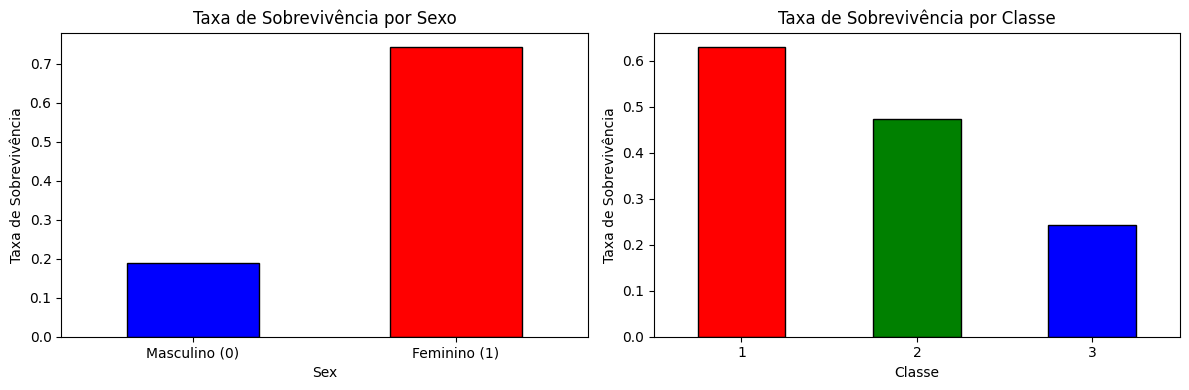

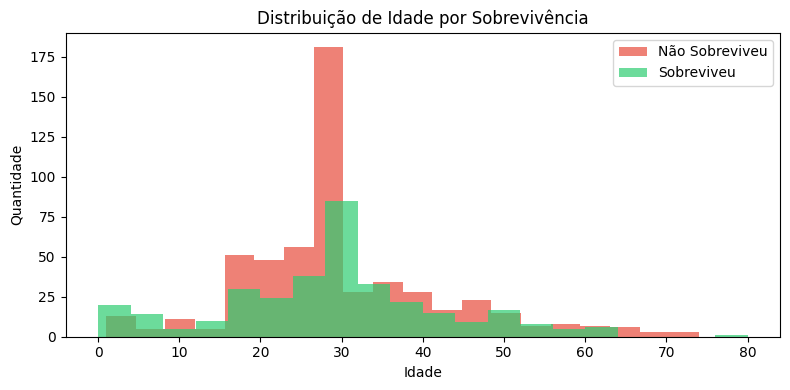

In [65]:
print("Valores Faltantes")
print(data_treino.isnull().sum())

print("\nDistribuição do Target")
print(data_treino['Survived'].value_counts())

# --- GRÁFICOS ---

# 1. Sobrevivência por Sexo e Classe
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data_treino.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0],
    color=['blue','red'], edgecolor='black', rot=0)
axes[0].set_title('Taxa de Sobrevivência por Sexo')
axes[0].set_xticklabels(['Masculino (0)', 'Feminino (1)'])
axes[0].set_ylabel('Taxa de Sobrevivência')

data_treino.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1],
    color=['red','green','blue'], edgecolor='black', rot=0)
axes[1].set_title('Taxa de Sobrevivência por Classe')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Taxa de Sobrevivência')

plt.tight_layout()
plt.show()

# 2. Distribuição de Idade por Sobrevivência
plt.figure(figsize=(8, 4))
plt.hist(data_treino[data_treino['Survived']==0]['Age'].dropna(),
         bins=20, alpha=0.7, label='Não Sobreviveu', color='#e74c3c')
plt.hist(data_treino[data_treino['Survived']==1]['Age'].dropna(),
         bins=20, alpha=0.7, label='Sobreviveu', color='#2ecc71')
plt.title('Distribuição de Idade por Sobrevivência')
plt.xlabel('Idade')
plt.ylabel('Quantidade')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Limpeza e Preparação Básica
>

In [52]:
data_treino['FamilySize'] = data_treino['SibSp'] + data_treino['Parch']
data_treino['Age'].fillna(data_treino['Age'].mean(), inplace=True)
data_treino['Fare'].replace(0, data_treino['Fare'].median(), inplace=True)
data_treino['Age'] = data_treino['Age'].astype(int)
data_treino['Sex'] = data_treino['Sex'].map({'male': 0, 'female': 1})
most_common_embarked = data_treino['Embarked'].mode()[0]
data_treino['Embarked'].fillna(most_common_embarked, inplace=True)
data_treino['Embarked'] = data_treino['Embarked'].map({'C': 1, 'Q': 2, 'S': 3})
data_treino.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis=1, inplace=True)

print("Dados após limpeza:")
print(data_treino.head())
print(f"\nShape final: {data_treino.shape}")

Dados após limpeza:
   Survived  Pclass  Sex  Age     Fare  Embarked  FamilySize
0         0       3    0   22   7.2500         3           1
1         1       1    1   38  71.2833         1           1
2         1       3    1   26   7.9250         3           0
3         1       1    1   35  53.1000         3           1
4         0       3    0   35   8.0500         3           0

Shape final: (891, 7)


## 4. Separar Treino e Teste (Antes de Qualquer Aumento)
>


In [53]:
df_train, df_test = train_test_split(data_treino, test_size=0.2, random_state=4)

X_train = df_train.drop('Survived', axis=1)
y_train = df_train['Survived']
X_test  = df_test.drop('Survived', axis=1)
y_test  = df_test['Survived']

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 712 amostras | Teste: 179 amostras


## 5. Pré-processamento (StandardScaler)

In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Tensores para PyTorch
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values.reshape(-1,1), dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values.reshape(-1,1),  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

## 6. Modelo MLP (PyTorch)


In [55]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32, hidden_size3=16, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size1), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_size1, hidden_size2), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_size2, hidden_size3), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_size3, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

# Hiperparâmetros
input_size    = X_train.shape[1]
learning_rate = 0.001
num_epochs    = 1000
weight_decay  = 1e-4

model     = MLP(input_size)
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


## 7. Treinamento

In [56]:
train_losses, test_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    model.eval()
    with torch.no_grad():
        test_losses.append(criterion(model(X_test_t), y_test_t).item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f}")

Epoch [100/1000] | Train Loss: 0.1756 | Test Loss: 0.1649
Epoch [200/1000] | Train Loss: 0.1683 | Test Loss: 0.1466
Epoch [300/1000] | Train Loss: 0.1556 | Test Loss: 0.1519
Epoch [400/1000] | Train Loss: 0.1563 | Test Loss: 0.1457
Epoch [500/1000] | Train Loss: 0.1657 | Test Loss: 0.1464
Epoch [600/1000] | Train Loss: 0.1600 | Test Loss: 0.1533
Epoch [700/1000] | Train Loss: 0.1544 | Test Loss: 0.1512
Epoch [800/1000] | Train Loss: 0.1577 | Test Loss: 0.1553
Epoch [900/1000] | Train Loss: 0.1520 | Test Loss: 0.1570
Epoch [1000/1000] | Train Loss: 0.1533 | Test Loss: 0.1536


## 8. Curva de Perda

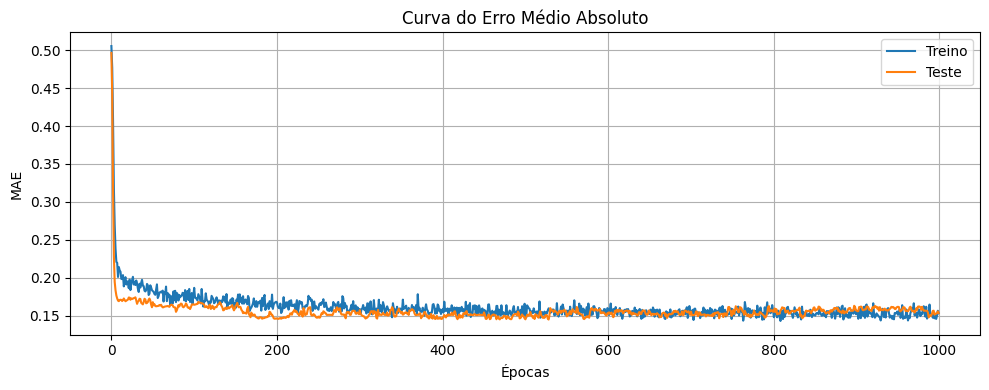

In [57]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Treino')
plt.plot(test_losses,  label='Teste')
plt.title('Curva do Erro Médio Absoluto')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. Avaliação — Modelo PyTorch

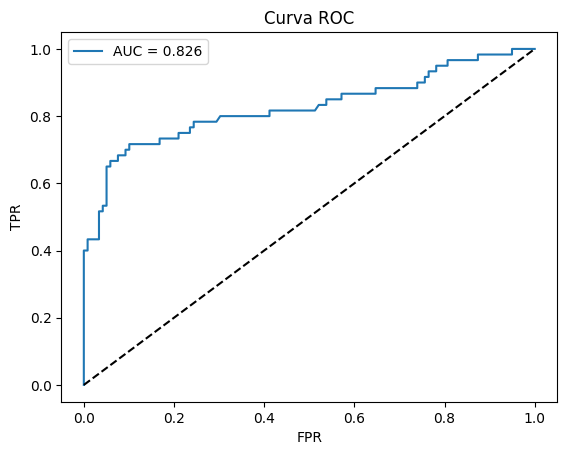


Teste
Acurácia: 0.8436
                precision    recall  f1-score   support

Não Sobreviveu       0.84      0.95      0.89       119
    Sobreviveu       0.86      0.63      0.73        60

      accuracy                           0.84       179
     macro avg       0.85      0.79      0.81       179
  weighted avg       0.85      0.84      0.84       179



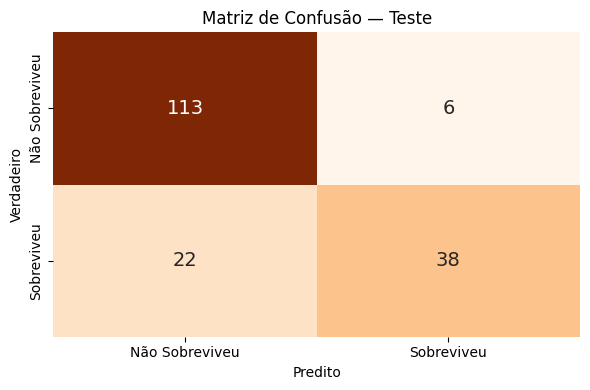


Treino
Acurácia: 0.8497
                precision    recall  f1-score   support

Não Sobreviveu       0.83      0.94      0.88       430
    Sobreviveu       0.89      0.71      0.79       282

      accuracy                           0.85       712
     macro avg       0.86      0.82      0.84       712
  weighted avg       0.85      0.85      0.85       712



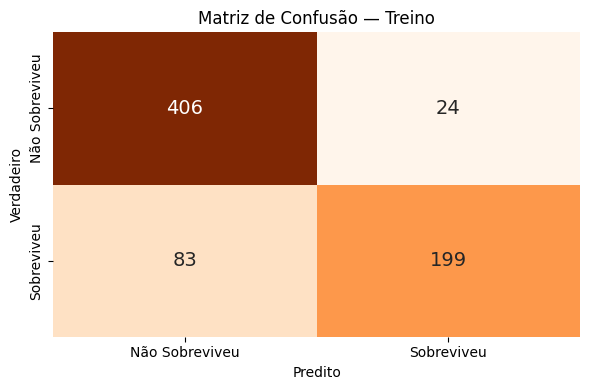

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score # Added for fix

def avaliar(model, X_t, y_t, titulo):
    model.eval()
    with torch.no_grad():
        y_pred = torch.round(model(X_t)).numpy()
    y_true = y_t.numpy()
    acc = accuracy_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred)
    print(f"\n{titulo}")
    print(f"Acurácia: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=['Não Sobreviveu','Sobreviveu']))
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False, annot_kws={"size":14},
                xticklabels=['Não Sobreviveu','Sobreviveu'],
                yticklabels=['Não Sobreviveu','Sobreviveu'])
    plt.title(f'Matriz de Confusão — {titulo}')
    plt.xlabel('Predito'); plt.ylabel('Verdadeiro')
    plt.tight_layout(); plt.show()
    return acc


y_prob = model_sk.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend(); plt.show()

acc_test  = avaliar(model, X_test_t,  y_test_t,  'Teste')
acc_train = avaliar(model, X_train_t, y_train_t, 'Treino')

## 10. Modelo Simplificado — MLPClassifier (sklearn)
Mesma arquitetura, menos código

In [59]:
model_sk = MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=1000, random_state=42)
model_sk.fit(X_train_scaled, y_train)

y_pred_sk = model_sk.predict(X_test_scaled)
print(f"Acurácia (sklearn MLP): {accuracy_score(y_test, y_pred_sk):.4f}")
print(classification_report(y_test, y_pred_sk, target_names=['Não Sobreviveu','Sobreviveu']))

Acurácia (sklearn MLP): 0.8324
                precision    recall  f1-score   support

Não Sobreviveu       0.85      0.91      0.88       119
    Sobreviveu       0.79      0.68      0.73        60

      accuracy                           0.83       179
     macro avg       0.82      0.80      0.81       179
  weighted avg       0.83      0.83      0.83       179



## 11. Importância das Features

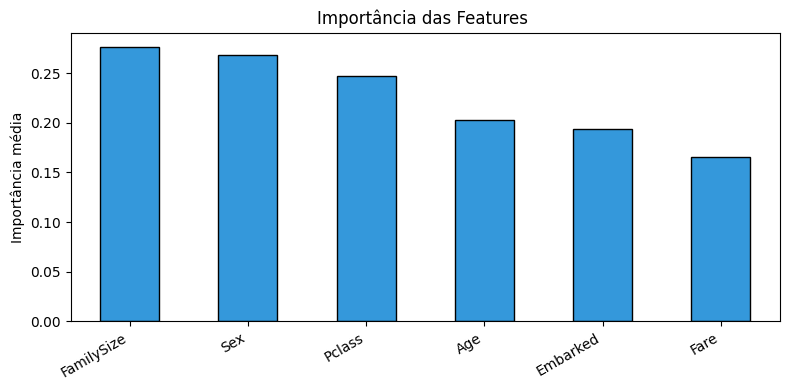

FamilySize    0.276725
Sex           0.267766
Pclass        0.246961
Age           0.202453
Embarked      0.193639
Fare          0.165421
dtype: float32


In [60]:
importances = np.mean(np.abs(model.net[0].weight.detach().numpy()), axis=0)
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(8, 4), color='#3498db', edgecolor='black')
plt.title('Importância das Features ')
plt.ylabel('Importância média')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(feat_imp)

## 12. Salvar o Modelo

Logistic Regression       → Acurácia: 0.8324
Random Forest             → Acurácia: 0.8212
MLP                       → Acurácia: 0.8324


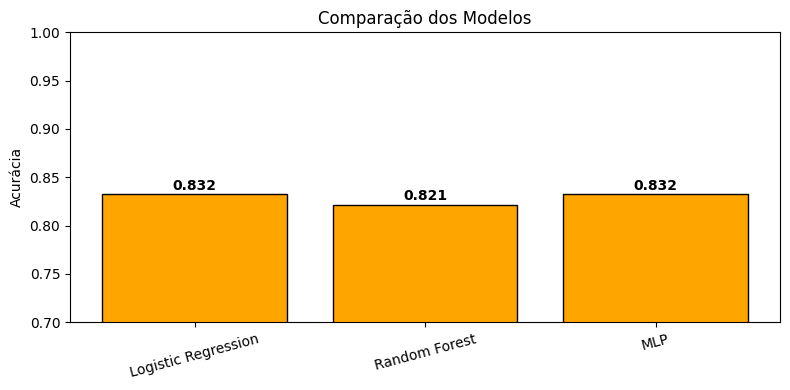

In [64]:
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'MLP':         MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=1000, random_state=42),
}

resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, modelo.predict(X_test_scaled))
    resultados[nome] = acc
    print(f'{nome:25s} → Acurácia: {acc:.4f}')

plt.figure(figsize=(8, 4))
plt.bar(resultados.keys(), resultados.values(), color='orange', edgecolor='black')
plt.ylim(0.7, 1.0)
plt.title('Comparação dos Modelos')
plt.ylabel('Acurácia')
plt.xticks(rotation=15)
for i, (k, v) in enumerate(resultados.items()):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()